In [ ]:
# https://www.analyticsvidhya.com/blog/2021/05/food-classification-using-transfer-learning-and-tensorflow/

# https://stackoverflow.com/questions/69109151/how-to-view-the-image-from-test-generator-to-see-if-the-prediction-is-correct-or

In [1]:
import tensorflow as tf
print(tf.__version__)

2.9.2


In [2]:
# More imports
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

In [3]:
# Data from: https://mmspg.epfl.ch/downloads/food-image-datasets/
# !wget --passive-ftp --prefer-family=ipv4 --ftp-user FoodImage@grebvm2.epfl.ch \
#  --ftp-password Cahc1moo -nc ftp://tremplin.epfl.ch/Food-5K.zip
!wget -nc https://lazyprogrammer.me/course_files/Food-5K.zip

--2023-02-06 16:05:04--  https://lazyprogrammer.me/course_files/Food-5K.zip
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 447001986 (426M) [application/zip]
Saving to: ‘Food-5K.zip’

Food-5K.zip          88%[================>   ] 375.17M   141KB/s    in 54m 38s 

2023-02-06 16:59:43 (117 KB/s) - Connection closed at byte 393398300. Retrying.

--2023-02-06 16:59:44--  (try: 2)  https://lazyprogrammer.me/course_files/Food-5K.zip
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 447001986 (426M), 53603686 (51M) remaining [application/zip]
Saving to: ‘Food-5K.zip’

Food-5K.zip         100%[+++++++++++++++++==>] 426.29M  18.9MB/s    in 2.7s    

2023-02-06 17:00:05 (18.9 MB/s) - ‘Food

In [5]:
!unzip -qq -o /content/Food-5K.zip

In [7]:
!ls training

0_0.jpg     0_1387.jpg	0_422.jpg  0_809.jpg   1_1195.jpg  1_230.jpg  1_617.jpg
0_1000.jpg  0_1388.jpg	0_423.jpg  0_80.jpg    1_1196.jpg  1_231.jpg  1_618.jpg
0_1001.jpg  0_1389.jpg	0_424.jpg  0_810.jpg   1_1197.jpg  1_232.jpg  1_619.jpg
0_1002.jpg  0_138.jpg	0_425.jpg  0_811.jpg   1_1198.jpg  1_233.jpg  1_61.jpg
0_1003.jpg  0_1390.jpg	0_426.jpg  0_812.jpg   1_1199.jpg  1_234.jpg  1_620.jpg
0_1004.jpg  0_1391.jpg	0_427.jpg  0_813.jpg   1_119.jpg   1_235.jpg  1_621.jpg
0_1005.jpg  0_1392.jpg	0_428.jpg  0_814.jpg   1_11.jpg    1_236.jpg  1_622.jpg
0_1006.jpg  0_1393.jpg	0_429.jpg  0_815.jpg   1_1200.jpg  1_237.jpg  1_623.jpg
0_1007.jpg  0_1394.jpg	0_42.jpg   0_816.jpg   1_1201.jpg  1_238.jpg  1_624.jpg
0_1008.jpg  0_1395.jpg	0_430.jpg  0_817.jpg   1_1202.jpg  1_239.jpg  1_625.jpg
0_1009.jpg  0_1396.jpg	0_431.jpg  0_818.jpg   1_1203.jpg  1_23.jpg   1_626.jpg
0_100.jpg   0_1397.jpg	0_432.jpg  0_819.jpg   1_1204.jpg  1_240.jpg  1_627.jpg
0_1010.jpg  0_1398.jpg	0_433.jpg  0_81.jpg    1_1205.j

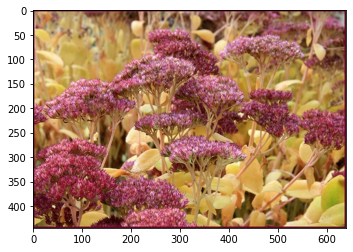

In [ ]:
plt.imshow(image.load_img("training/0_808.jpg"));

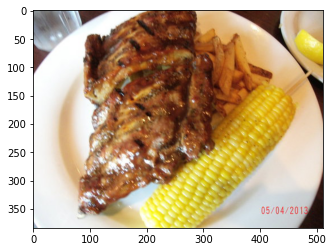

In [ ]:
# Food images start with 1, non-food images start with 0
plt.imshow(image.load_img('training/1_503.jpg'))
plt.show()

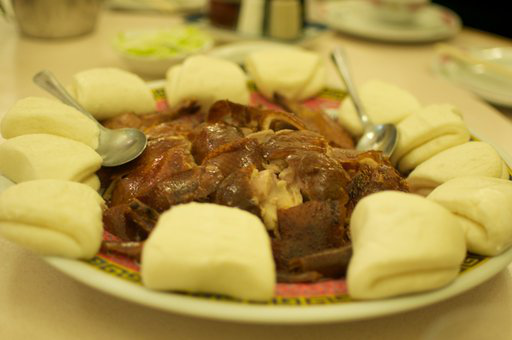

In [ ]:
image.load_img('/content/data/test/food/1_0.jpg')

In [8]:
!mkdir data

In [9]:
# Make directories to store the data Keras-style
!mkdir data/train
!mkdir data/validate
!mkdir data/test

!mkdir data/train/nonfood
!mkdir data/train/food

!mkdir data/validate/nonfood
!mkdir data/validate/food

!mkdir data/test/nonfood
!mkdir data/test/food

In [10]:
# Move the images

!mv training/0*.jpg data/train/nonfood
!mv training/1*.jpg data/train/food

!mv validation/0*.jpg data/validate/nonfood
!mv validation/1*.jpg data/validate/food

!mv evaluation/0*.jpg data/test/nonfood
!mv evaluation/1*.jpg data/test/food

In [11]:
train_path = 'data/train'
valid_path = 'data/validate'
test_path = 'data/test'

In [12]:
# These images are pretty big and of different sizes
# Let's load them all in as the same (smaller) size
image_size = [200, 200]

In [13]:
# useful for getting number of files
image_files = glob(train_path + '/*/*.jpg')
valid_image_files = glob(valid_path + '/*/*.jpg')

In [14]:
folders = glob(train_path + '/*')
folders

['data/train/food', 'data/train/nonfood']

In [15]:
vgg16_model = VGG16(
    input_shape=image_size + [3],
    weights='imagenet',
    include_top=False
)

58889256/58889256 [==============================] - 0s 0us/step


In [16]:
vgg16_model.trainable = False

In [17]:
K = len(folders)

x = Flatten()(vgg16_model.output)
x = Dense(K, activation='softmax')(x)

In [18]:
model = Model(inputs=vgg16_model.input, outputs=x)

In [19]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 200, 200, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 200, 200, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 100, 100, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 100, 100, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 100, 100, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 50, 50, 128)       0     

In [20]:
gen_train = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    preprocessing_function=preprocess_input
)

gen_valid = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

In [21]:
batch_size = 128

# create generators
train_generator = gen_train.flow_from_directory(
  train_path,
  shuffle=True,
  target_size=image_size,
  batch_size=batch_size,
)
valid_generator = gen_valid.flow_from_directory(
  valid_path,
  target_size=image_size,
  batch_size=batch_size,
)

Found 3000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [22]:
import math
n_epochs = 5

n_steps = n_epochs * math.ceil(3000 / batch_size)
scheduled_learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
initial_learning_rate=0.001, decay_steps=n_steps, decay_rate=0.01)

optimizer = tf.keras.optimizers.Adam(learning_rate=scheduled_learning_rate)

In [23]:
model.compile(
  loss='categorical_crossentropy',
  optimizer=optimizer,
  metrics=['accuracy']
)

In [24]:
r = model.fit(
  train_generator,
  validation_data=valid_generator,
  epochs=n_epochs,
  steps_per_epoch=int(np.ceil(len(image_files) / batch_size)),
  validation_steps=int(np.ceil(len(valid_image_files) / batch_size)),
)

Epoch 1/5
24/24 [==============================] - 72s 2s/step - loss: 2.5716 - accuracy: 0.8967 - val_loss: 0.6582 - val_accuracy: 0.9660
Epoch 2/5
24/24 [==============================] - 48s 2s/step - loss: 0.5523 - accuracy: 0.9753 - val_loss: 0.3719 - val_accuracy: 0.9740
Epoch 3/5
24/24 [==============================] - 47s 2s/step - loss: 0.4913 - accuracy: 0.9747 - val_loss: 0.3531 - val_accuracy: 0.9760
Epoch 4/5
24/24 [==============================] - 48s 2s/step - loss: 0.3668 - accuracy: 0.9773 - val_loss: 0.3606 - val_accuracy: 0.9740
Epoch 5/5
24/24 [==============================] - 47s 2s/step - loss: 0.3988 - accuracy: 0.9750 - val_loss: 0.3666 - val_accuracy: 0.9750


The trained model will still be in memory, in the state it was in when the KeyboardInterrupt happened. As long as the Python kernel isn't stopped or the model isn't reinstantiated, you can continue to use the trained model. To test this, evaluate the model's prediction accuracy.

Note that, if you continue training the model, a KeyboardInterrupt restarts the epoch counter. That will effect any callbacks that rely on the epoch number.

In [25]:
gen_test = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

test_generator = gen_test.flow_from_directory(
  test_path,
  target_size=image_size,
  shuffle=False,
  seed=42,
  
)

Found 1000 images belonging to 2 classes.


In [26]:
model.evaluate(valid_generator)

8/8 [==============================] - 7s 751ms/step - loss: 0.3666 - accuracy: 0.9750


[0.3666207194328308, 0.9750000238418579]

In [27]:
model.evaluate(test_generator, steps=int(np.ceil(len(valid_image_files) / batch_size)))

8/8 [==============================] - 4s 170ms/step - loss: 0.2672 - accuracy: 0.9883


[0.26724672317504883, 0.98828125]

In [60]:
model.evaluate(test_generator)

32/32 [==============================] - 12s 375ms/step - loss: 0.6051 - accuracy: 0.9740


[0.6050652265548706, 0.9739999771118164]

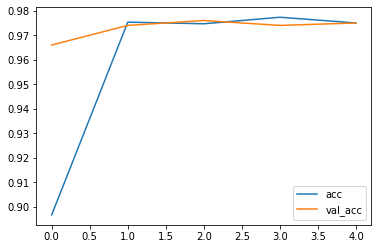

In [29]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend();

In [30]:
model.predict(test_generator)

32/32 [==============================] - 12s 377ms/step


array([[1.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00],
       ...,
       [1.4459437e-24, 1.0000000e+00],
       [2.5329796e-25, 1.0000000e+00],
       [2.6574531e-36, 1.0000000e+00]], dtype=float32)

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [61]:
#Confution Matrix and Classification Report
# https://gist.github.com/RyanAkilos/3808c17f79e77c4117de35aa68447045

Y_pred = model.predict(test_generator)

y_pred = np.argmax(Y_pred, axis=1)

print('Classification Report')
target_names = ['Nonfood', "Food"]
print(classification_report(test_generator.classes, y_pred, target_names=target_names))

32/32 [==============================] - 12s 378ms/step
Classification Report
              precision    recall  f1-score   support

     Nonfood       0.98      0.97      0.97       500
        Food       0.97      0.98      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



Confusion Matrix


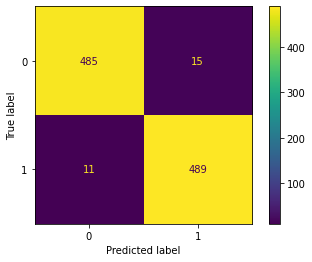

In [33]:
print('Confusion Matrix')
ConfusionMatrixDisplay(confusion_matrix(test_generator.classes, y_pred)).plot();

In [88]:
np.where(test_generator.classes != y_pred)

(array([150, 216, 249, 352, 356, 364, 369, 370, 385, 401, 415, 416, 436,
        444, 459, 535, 561, 572, 656, 658, 691, 736, 888, 890, 951, 980]),)

In [113]:
test_generator.filepaths[216]

'data/test/food/1_293.jpg'

In [107]:
test_generator.filenames[150]

'food/1_233.jpg'

In [102]:
y_pred[150]

1

In [98]:
test_generator.classes[:500]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [117]:
np.where(test_generator.classes != y_pred)

(array([150, 216, 249, 352, 356, 364, 369, 370, 385, 401, 415, 416, 436,
        444, 459, 535, 561, 572, 656, 658, 691, 736, 888, 890, 951, 980]),)

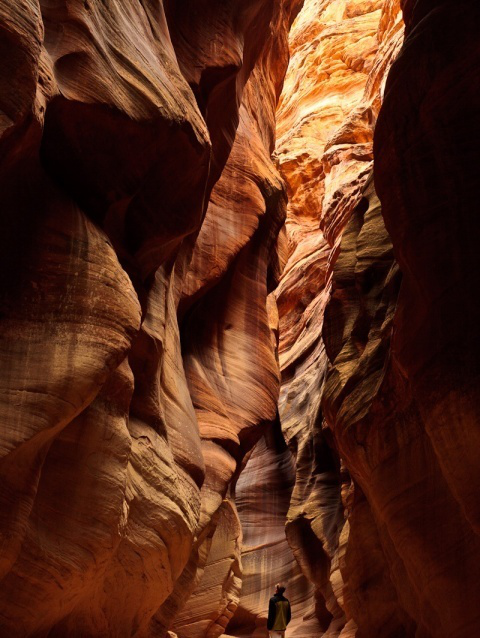

In [120]:
image.load_img(test_generator.filepaths[736])